In [1]:
# ============================================================
# 0A. Threading MUST be configured before NumPy/PySCF imports
# ============================================================
import os

REQUESTED_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", os.environ.get("H2X2_THREADS", "64")))
REQUESTED_THREADS = max(1, REQUESTED_THREADS)

for _var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = str(REQUESTED_THREADS)

print("Requested CPU threads:", REQUESTED_THREADS)

Requested CPU threads: 64


In [2]:
# ============================================================
# 0B. Imports, constants, publication settings, output tree
# ============================================================
from pathlib import Path
import json, csv, time, platform, sys, hashlib, subprocess, warnings, socket
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline, PchipInterpolator
from scipy.linalg import eigh
from scipy.integrate import cumulative_trapezoid

np.set_printoptions(precision=10, suppress=True)

MOLECULE = 'H2O2'
CFG = {'RXH0': 0.97,
'RXX0': 1.475,
'X': 'O',
'basis_qz': {'H': 'aug-cc-pvqz', 'O': 'aug-cc-pvqz'},
'basis_tz': {'H': 'aug-cc-pvtz', 'O': 'aug-cc-pvtz'},
'benchmark_alternatives': {'experiment_cm-1': 11.44},
'benchmark_label': 'experimental ground-state torsional splitting',
'benchmark_primary_cm': 11.44,
'bounds': [(1.25, 1.8), (0.82, 1.15), (78.0, 112.0)],
'ecp_qz': {},
'ecp_tz': {},
'experimental_levels_cm': [0.0, 11.44, 254.2, 370.7, 569.3, 775.9],
'frozen_nmo': 2,
'name': 'H2O2',
'phi_eq': 111.5,
'sahu_barrier_cm': {'cis': 2924.3, 'trans': 368.4},
'theta0': 95.0}

# Final production settings.
RUN_AB_INITIO = True
RUN_CCSDT = True
RUN_PBE0_DIPOLE = True
RUN_STATIONARY_POINT_CHECKS = True
RUN_BASIS_SET_CHECK = True
RUN_CCSD_DIPOLE_DIAGNOSTIC = True

RELAX_METHOD = "MP2"
SCAN_STEP_DEG = 5.0
N_DVR_FINAL = 384
N_DVR_CONVERGENCE = (96, 128, 192, 256, 384, 512)
N_ARCLENGTH_MAP = 4097

SCF_CONV_TOL = 1e-10
CC_CONV_TOL = 1e-9
MAX_SCF_CYCLE = 250
OPT_XTOL = 1e-4
OPT_FTOL = 2e-10
OPT_MAXITER = 160

# Readiness thresholds: intentionally conservative.
DVR_LAST3_FACTOR_TOL = 1.05
QUANTITATIVE_SPLIT_FACTOR = 3.0
ORDER_ONLY_SPLIT_FACTOR = 10.0
T1_CAUTION = 0.020
T1_FAIL = 0.030
BASIS_BARRIER_SHIFT_CAUTION_KCAL = 0.20
DIRECT_DIPOLE_DARK_D = 1e-6

# Physical constants.
HARTREE_TO_CM = 219474.6313705
HARTREE_TO_KCAL = 627.5094740631
ANG_TO_BOHR = 1.8897261254578281
AMU_TO_ME = 1822.888486209
C_CM_S = 2.99792458e10
DEBYE_C_M = 3.33564e-30

MASS_AMU = {"H": 1.00784, "O": 15.999, "S": 32.06, "Se": 78.971}

# Shared root: all three molecule notebooks should use the same parent directory.
PROJECT_ROOT = Path(os.environ.get("H2X2_PROJECT_ROOT",
                                   str(Path.cwd() / "H2X2_publication_project"))).resolve()
MOL_ROOT = PROJECT_ROOT / "data" / MOLECULE
CACHE_DIR = MOL_ROOT / "cache"
RAW_DIR = MOL_ROOT / "raw"
GEOM_DIR = RAW_DIR / "geometries"
PROC_DIR = MOL_ROOT / "processed"
VALID_DIR = MOL_ROOT / "validation"
META_DIR = MOL_ROOT / "metadata"
FIG_DIR = MOL_ROOT / "figures"

for _p in (CACHE_DIR, RAW_DIR, GEOM_DIR, PROC_DIR, VALID_DIR, META_DIR, FIG_DIR):
    _p.mkdir(parents=True, exist_ok=True)

print("Molecule:", MOLECULE)
print("Project root:", PROJECT_ROOT)
print("Output directory:", MOL_ROOT)


Molecule: H2O2
Project root: /home/smohtash/H2X2_final/H2X2_publication_project
Output directory: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2


In [3]:
def _safe_pkg_version(pkg):
    try:
        import importlib.metadata as im
        return im.version(pkg)
    except Exception:
        return None

def _git_commit_here():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL, text=True
        ).strip()
    except Exception:
        return None

def base_metadata():
    return {
        "molecule": MOLECULE,
        "workflow_revision": "H2O2_rotation_projected_arc_length_v2",
        "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "hostname": socket.gethostname(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "scipy": _safe_pkg_version("scipy"),
        "matplotlib": _safe_pkg_version("matplotlib"),
        "pyscf": _safe_pkg_version("pyscf"),
        "basis_set_exchange": _safe_pkg_version("basis_set_exchange"),
        "threads": REQUESTED_THREADS,
        "slurm_job_id": os.environ.get("SLURM_JOB_ID"),
        "slurm_cpus_per_task": os.environ.get("SLURM_CPUS_PER_TASK"),
        "slurm_mem_per_node": os.environ.get("SLURM_MEM_PER_NODE"),
        "git_commit": _git_commit_here(),
        "config": CFG,
        "settings": {
            "RUN_CCSDT": RUN_CCSDT,
            "RUN_PBE0_DIPOLE": RUN_PBE0_DIPOLE,
            "RUN_STATIONARY_POINT_CHECKS": RUN_STATIONARY_POINT_CHECKS,
            "RUN_BASIS_SET_CHECK": RUN_BASIS_SET_CHECK,
            "RUN_CCSD_DIPOLE_DIAGNOSTIC": RUN_CCSD_DIPOLE_DIAGNOSTIC,
            "RELAX_METHOD": RELAX_METHOD,
            "SCAN_STEP_DEG": SCAN_STEP_DEG,
            "N_DVR_FINAL": N_DVR_FINAL,
            "N_DVR_CONVERGENCE": list(N_DVR_CONVERGENCE),
            "N_ARCLENGTH_MAP": N_ARCLENGTH_MAP,
            "reaction_path_metric": "COM + rigid rotation projected; Kabsch/projector cross-validated",
            "DVR_coordinate": "uniform internal arc-length chi",
            "SCF_CONV_TOL": SCF_CONV_TOL,
            "CC_CONV_TOL": CC_CONV_TOL,
        },
    }

(META_DIR / "run_metadata_preflight.json").write_text(
    json.dumps(base_metadata(), indent=2)
)
print(json.dumps(base_metadata(), indent=2)[:3000])


{
  "molecule": "H2O2",
  "workflow_revision": "H2O2_rotation_projected_arc_length_v2",
  "timestamp_utc": "2026-08-30T23:23:06Z",
  "hostname": "bell-a066.rcac.purdue.edu",
  "python": "3.13.2 | packaged by conda-forge | (main, Feb 17 2025, 14:10:22) [GCC 13.3.0]",
  "platform": "Linux-4.18.0-553.123.1.el8_10.x86_64-x86_64-with-glibc2.28",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "pyscf": "2.14.0",
  "basis_set_exchange": null,
  "threads": 64,
  "slurm_job_id": "1319218",
  "slurm_cpus_per_task": "64",
  "slurm_mem_per_node": null,
  "git_commit": null,
  "config": {
    "RXH0": 0.97,
    "RXX0": 1.475,
    "X": "O",
    "basis_qz": {
      "H": "aug-cc-pvqz",
      "O": "aug-cc-pvqz"
    },
    "basis_tz": {
      "H": "aug-cc-pvtz",
      "O": "aug-cc-pvtz"
    },
    "benchmark_alternatives": {
      "experiment_cm-1": 11.44
    },
    "benchmark_label": "experimental ground-state torsional splitting",
    "benchmark_primary_cm": 11.44,
    "bounds": [


In [4]:
def hxxh_geometry(RXX, RXH, theta_deg, phi_deg):
    X = CFG["X"]
    theta = np.deg2rad(theta_deg)
    phi = np.deg2rad(phi_deg)

    X1 = np.array([-RXX/2, 0.0, 0.0])
    X2 = np.array([+RXX/2, 0.0, 0.0])

    H1 = X1 + RXH*np.array([np.cos(theta), np.sin(theta), 0.0])
    H2 = X2 + RXH*np.array([
        -np.cos(theta),
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
    ])
    return ["H", X, X, "H"], np.vstack([H1, X1, X2, H2])

def dihedral_deg(coords):
    p0,p1,p2,p3 = np.asarray(coords,float)
    b0 = -(p1-p0)
    b1 = p2-p1
    b2 = p3-p2
    b1 = b1/np.linalg.norm(b1)
    v = b0 - np.dot(b0,b1)*b1
    w = b2 - np.dot(b2,b1)*b1
    return np.rad2deg(np.arctan2(np.dot(np.cross(b1,v),w), np.dot(v,w)))

def center_of_mass_shift(symbols, coords_A):
    m = np.array([MASS_AMU[s] for s in symbols], float)
    xyz = np.asarray(coords_A,float)
    com = np.sum(m[:,None]*xyz, axis=0)/m.sum()
    return xyz-com

syms0, xyz0 = hxxh_geometry(CFG["RXX0"], CFG["RXH0"], CFG["theta0"], CFG["phi_eq"])
print("Initial dihedral:", dihedral_deg(xyz0))
print("Initial coordinates (Angstrom):\n", xyz0)

Initial dihedral: 111.5
Initial coordinates (Angstrom):
 [[-0.8220410705  0.9663088571  0.          ]
 [-0.7375        0.            0.          ]
 [ 0.7375        0.            0.          ]
 [ 0.8220410705 -0.3541533815  0.8990707368]]


In [5]:
try:
    import pyscf
    from pyscf import gto, scf, dft, mp, cc, lib
    from pyscf.hessian import thermo
    HAVE_PYSCF = True
    lib.num_threads(REQUESTED_THREADS)
except Exception as exc:
    HAVE_PYSCF = False
    PYSCF_IMPORT_ERROR = repr(exc)

def require_pyscf():
    if not HAVE_PYSCF:
        raise RuntimeError(
            "PySCF is required for the production calculation. "
            "Install it in the Bell kernel (for example `pip install pyscf`) "
            "and restart the kernel. Import error: " + PYSCF_IMPORT_ERROR
        )

def available_memory_mb(fraction=0.75):
    try:
        pages = os.sysconf("SC_PHYS_PAGES")
        page_size = os.sysconf("SC_PAGE_SIZE")
        return int(pages*page_size/1024**2*fraction)
    except Exception:
        return 16000

MAX_MEMORY_MB = int(os.environ.get("PYSCF_MAX_MEMORY_MB", available_memory_mb()))
print("PySCF available:", HAVE_PYSCF)
print("PySCF max memory per process (MB):", MAX_MEMORY_MB)

def build_mol(symbols, coords_A, basis=None, ecp=None):
    require_pyscf()
    basis = CFG["basis_tz"] if basis is None else basis
    ecp = CFG["ecp_tz"] if ecp is None else ecp
    atom = [[s, tuple(map(float,r))] for s,r in zip(symbols,np.asarray(coords_A))]
    try:
        mol = gto.M(
            atom=atom, unit="Angstrom",
            basis=basis, ecp=ecp,
            charge=0, spin=0, cart=False, verbose=0
        )
    except Exception as exc:
        raise RuntimeError(
            f"Failed to build {MOLECULE} with the explicitly requested basis/ECP. "
            "Do not substitute a different basis silently. "
            f"basis={basis}, ecp={ecp}"
        ) from exc
    mol.max_memory = MAX_MEMORY_MB
    return mol

def rhf_reference(mol):
    mf = scf.RHF(mol)
    mf.conv_tol = SCF_CONV_TOL
    mf.max_cycle = MAX_SCF_CYCLE
    mf.verbose = 0
    mf.kernel()
    if not mf.converged:
        mf = mf.newton()
        mf.conv_tol = SCF_CONV_TOL
        mf.max_cycle = MAX_SCF_CYCLE
        mf.kernel()
    if not mf.converged:
        raise RuntimeError("RHF failed to converge.")
    return mf

def mp2_energy(symbols, coords_A, basis=None, ecp=None):
    mol = build_mol(symbols, coords_A, basis=basis, ecp=ecp)
    mf = rhf_reference(mol)
    pt = mp.MP2(mf, frozen=CFG["frozen_nmo"])
    pt.verbose = 0
    pt.kernel()
    if not getattr(pt, "converged", True):
        raise RuntimeError("MP2 failed to converge.")
    return float(pt.e_tot)

def pbe0_energy(symbols, coords_A, basis=None, ecp=None):
    mol = build_mol(symbols, coords_A, basis=basis, ecp=ecp)
    mf = dft.RKS(mol)
    mf.xc = "PBE0"
    mf.grids.level = 4
    mf.conv_tol = SCF_CONV_TOL
    mf.max_cycle = MAX_SCF_CYCLE
    mf.verbose = 0
    mf.kernel()
    if not mf.converged:
        raise RuntimeError("PBE0 failed to converge.")
    return float(mf.e_tot)

def pbe0_dipole_D(symbols, coords_A, basis=None, ecp=None):
    mol = build_mol(symbols, coords_A, basis=basis, ecp=ecp)
    mf = dft.RKS(mol)
    mf.xc = "PBE0"
    mf.grids.level = 4
    mf.conv_tol = SCF_CONV_TOL
    mf.max_cycle = MAX_SCF_CYCLE
    mf.verbose = 0
    mf.kernel()
    if not mf.converged:
        raise RuntimeError("PBE0 dipole reference failed to converge.")
    mu = mf.dip_moment(mol=mol, dm=mf.make_rdm1(), unit="Debye", verbose=0)
    return np.asarray(mu,float)

def ccsd_t_properties(symbols, coords_A, basis=None, ecp=None, make_ccsd_dipole=False):
    mol = build_mol(symbols, coords_A, basis=basis, ecp=ecp)
    mf = rhf_reference(mol)
    mycc = cc.CCSD(mf, frozen=CFG["frozen_nmo"])
    mycc.conv_tol = CC_CONV_TOL
    mycc.max_cycle = 160
    mycc.verbose = 0
    mycc.kernel()
    if not mycc.converged:
        raise RuntimeError("CCSD failed to converge.")
    et = float(mycc.e_tot + mycc.ccsd_t())

    n_corr_e = max(1, mol.nelectron - 2*int(CFG["frozen_nmo"]))
    t1_diag = float(np.linalg.norm(mycc.t1)/np.sqrt(n_corr_e))

    mu_ccsd = None
    if make_ccsd_dipole:
        mycc.solve_lambda()
        dm1 = mycc.make_rdm1(ao_repr=True)
        mu_ccsd = np.asarray(
            mf.dip_moment(mol=mol, dm=dm1, unit="Debye", verbose=0), float
        )

    return {
        "E_ccsdt_ha": et,
        "T1_diagnostic": t1_diag,
        "dipole_ccsd_unrelaxed_D": None if mu_ccsd is None else mu_ccsd,
    }

if RUN_AB_INITIO:
    require_pyscf()
    # Build the initial geometry now so basis/ECP problems fail before a long scan.
    _testmol = build_mol(syms0, xyz0)
    print("Basis/ECP preflight passed. nao =", _testmol.nao_nr())

PySCF available: True
PySCF max memory per process (MB): 193101
Basis/ECP preflight passed. nao = 138


In [6]:
def energy_for_relax(symbols, coords_A, method):
    method = method.upper()
    if method == "MP2":
        return mp2_energy(symbols, coords_A)
    if method == "PBE0":
        return pbe0_energy(symbols, coords_A)
    raise ValueError(method)

def relax_phi(phi_deg, q0=None, method=RELAX_METHOD, verbose=False):
    if q0 is None:
        q0 = np.array([CFG["RXX0"], CFG["RXH0"], CFG["theta0"]], float)
    q0 = np.asarray(q0,float)
    memo = {}

    def objective(q):
        key = tuple(np.round(np.asarray(q,float), 8))
        if key in memo:
            return memo[key]
        syms, xyz = hxxh_geometry(q[0],q[1],q[2],phi_deg)
        try:
            e = energy_for_relax(syms, xyz, method)
        except Exception as exc:
            if verbose:
                print("energy failure:", exc)
            e = 1e3
        memo[key] = e
        if verbose:
            print(f"phi={phi_deg:8.3f} q={np.asarray(q)} E={e:.12f}")
        return e

    t0 = time.perf_counter()
    res = minimize(
        objective, q0, method="Powell", bounds=CFG["bounds"],
        options={"xtol":OPT_XTOL, "ftol":OPT_FTOL,
                 "maxiter":OPT_MAXITER, "disp":False}
    )
    elapsed = time.perf_counter()-t0
    q = np.asarray(res.x,float)
    syms, xyz = hxxh_geometry(q[0],q[1],q[2],phi_deg)
    E = energy_for_relax(syms, xyz, method)

    near_bound = []
    for val,(lo,hi) in zip(q, CFG["bounds"]):
        near_bound.append(min(val-lo, hi-val) < 2e-3)

    point = {
        "phi_deg": float(phi_deg),
        "q": q,
        "symbols": syms,
        "coords_A": xyz,
        "E_relax_ha": float(E),
        "relax_method": method,
        "optimizer_success": bool(res.success),
        "optimizer_message": str(res.message),
        "optimizer_nfev": int(res.nfev),
        "optimizer_elapsed_s": float(elapsed),
        "near_bound": [bool(x) for x in near_bound],
    }
    if not res.success:
        raise RuntimeError(f"Constrained optimization failed at phi={phi_deg}: {res.message}")
    return point

def production_phi_grid(step_deg=SCAN_STEP_DEG):
    base = np.arange(0.0, 180.0+0.1*step_deg, step_deg)
    eq = CFG["phi_eq"]
    refine = np.array([
        0.0, 2.5, 5.0,
        max(0.0,eq-5.0), max(0.0,eq-2.5), eq,
        min(180.0,eq+2.5), min(180.0,eq+5.0),
        175.0, 177.5, 180.0
    ])
    return np.unique(np.round(np.concatenate([base,refine]), 6))

PHI_POS = production_phi_grid()
print("Positive-branch points:", len(PHI_POS))
print(PHI_POS)

Positive-branch points: 44
[  0.    2.5   5.   10.   15.   20.   25.   30.   35.   40.   45.   50.
  55.   60.   65.   70.   75.   80.   85.   90.   95.  100.  105.  106.5
 109.  110.  111.5 114.  115.  116.5 120.  125.  130.  135.  140.  145.
 150.  155.  160.  165.  170.  175.  177.5 180. ]


In [7]:
CACHE_FILE = CACHE_DIR / "scan.json"

def jsonify_point(p):
    out = dict(p)
    for k in ("q","coords_A","dipole_pbe0_D","dipole_ccsd_unrelaxed_D"):
        if k in out and out[k] is not None:
            out[k] = np.asarray(out[k]).tolist()
    return out

def load_cache():
    if not CACHE_FILE.exists():
        return {}
    raw = json.loads(CACHE_FILE.read_text())
    return {float(k):v for k,v in raw.items()}

def save_cache(data):
    serial = {str(float(k)): jsonify_point(v) for k,v in data.items()}
    tmp = CACHE_FILE.with_suffix(".tmp")
    tmp.write_text(json.dumps(serial, indent=2))
    tmp.replace(CACHE_FILE)

def write_xyz(point):
    p = GEOM_DIR / f"phi_{point['phi_deg']:07.2f}.xyz"
    lines = [str(len(point["symbols"])),
             f"{MOLECULE} phi={point['phi_deg']:.6f} deg"]
    for s,r in zip(point["symbols"], np.asarray(point["coords_A"],float)):
        lines.append(f"{s:2s} {r[0]: .12f} {r[1]: .12f} {r[2]: .12f}")
    p.write_text("\n".join(lines)+"\n")

def ccsd_dipole_angle(phi):
    probes = np.array([30.0,60.0,CFG["phi_eq"],120.0,150.0])
    return bool(np.min(np.abs(probes-float(phi))) <= 1.3)

def point_ready(p):
    required = ["E_relax_ha","q","coords_A","optimizer_success"]
    if not all(k in p for k in required):
        return False
    if RUN_CCSDT and not np.isfinite(p.get("E_ccsdt_ha",np.nan)):
        return False
    if RUN_PBE0_DIPOLE:
        mu = p.get("dipole_pbe0_D")
        if mu is None or not np.all(np.isfinite(mu)):
            return False
    return bool(p.get("optimizer_success",False))

def enrich_point(point):
    syms = point["symbols"]
    xyz = np.asarray(point["coords_A"],float)

    if RUN_CCSDT:
        t0 = time.perf_counter()
        props = ccsd_t_properties(
            syms, xyz,
            make_ccsd_dipole=(RUN_CCSD_DIPOLE_DIAGNOSTIC and ccsd_dipole_angle(point["phi_deg"]))
        )
        point.update(props)
        point["ccsdt_elapsed_s"] = float(time.perf_counter()-t0)
    else:
        point["E_ccsdt_ha"] = np.nan
        point["T1_diagnostic"] = np.nan

    if RUN_PBE0_DIPOLE:
        t0 = time.perf_counter()
        point["dipole_pbe0_D"] = pbe0_dipole_D(syms, xyz)
        point["dipole_pbe0_elapsed_s"] = float(time.perf_counter()-t0)
    else:
        point["dipole_pbe0_D"] = [np.nan,np.nan,np.nan]

    return point

def run_scan():
    data = load_cache()
    p_eq = float(PHI_POS[np.argmin(np.abs(PHI_POS-CFG["phi_eq"]))])

    # Equilibrium-nearest point first.
    if p_eq in data and point_ready(data[p_eq]):
        qeq = np.asarray(data[p_eq]["q"],float)
        print("cached equilibrium-nearest:", p_eq)
    else:
        print("\n=== equilibrium-nearest phi =", p_eq, "===")
        p = enrich_point(relax_phi(p_eq))
        data[p_eq] = jsonify_point(p)
        save_cache(data); write_xyz(p)
        qeq = np.asarray(p["q"],float)

    # Walk from equilibrium toward cis.
    q = qeq.copy()
    for phi in sorted([x for x in PHI_POS if x < p_eq], reverse=True):
        phi = float(phi)
        if phi in data and point_ready(data[phi]):
            q = np.asarray(data[phi]["q"],float)
            print("cached", phi)
            continue
        print("\n=== phi =", phi, "deg (toward cis) ===")
        p = enrich_point(relax_phi(phi, q0=q))
        q = np.asarray(p["q"],float)
        data[phi] = jsonify_point(p)
        save_cache(data); write_xyz(p)

    # Independently walk from equilibrium toward trans.
    q = qeq.copy()
    for phi in sorted([x for x in PHI_POS if x > p_eq]):
        phi = float(phi)
        if phi in data and point_ready(data[phi]):
            q = np.asarray(data[phi]["q"],float)
            print("cached", phi)
            continue
        print("\n=== phi =", phi, "deg (toward trans) ===")
        p = enrich_point(relax_phi(phi, q0=q))
        q = np.asarray(p["q"],float)
        data[phi] = jsonify_point(p)
        save_cache(data); write_xyz(p)

    return load_cache()

SCAN = run_scan() if RUN_AB_INITIO else load_cache()
print("Completed/cached points:", len(SCAN), "/", len(PHI_POS))
missing = [float(p) for p in PHI_POS if float(p) not in SCAN or not point_ready(SCAN[float(p)])]
print("Missing/not-ready:", missing)

cached equilibrium-nearest: 111.5
cached 110.0
cached 109.0
cached 106.5
cached 105.0
cached 100.0
cached 95.0
cached 90.0
cached 85.0
cached 80.0
cached 75.0
cached 70.0
cached 65.0
cached 60.0
cached 55.0
cached 50.0
cached 45.0
cached 40.0
cached 35.0
cached 30.0
cached 25.0
cached 20.0
cached 15.0
cached 10.0
cached 5.0
cached 2.5
cached 0.0
cached 114.0
cached 115.0
cached 116.5
cached 120.0
cached 125.0
cached 130.0
cached 135.0
cached 140.0
cached 145.0
cached 150.0
cached 155.0
cached 160.0
cached 165.0
cached 170.0
cached 175.0
cached 177.5
cached 180.0
Completed/cached points: 44 / 44
Missing/not-ready: []


In [8]:
def scan_arrays(scan):
    phi = np.array(sorted(scan),float)
    rows = [scan[p] for p in phi]
    Er = np.array([r["E_relax_ha"] for r in rows],float)
    Ec = np.array([r.get("E_ccsdt_ha",np.nan) for r in rows],float)
    q = np.array([r["q"] for r in rows],float)
    mu = np.array([r.get("dipole_pbe0_D",[np.nan]*3) for r in rows],float)
    t1 = np.array([r.get("T1_diagnostic",np.nan) for r in rows],float)
    success = np.array([bool(r.get("optimizer_success",False)) for r in rows])
    Euse = Ec if np.all(np.isfinite(Ec)) else Er
    source = "CCSD(T)//MP2" if np.all(np.isfinite(Ec)) else RELAX_METHOD
    return {"phi":phi,"Er":Er,"Ec":Ec,"Euse":Euse,"q":q,"mu":mu,"t1":t1,
            "success":success,"source":source,"rows":rows}

A = scan_arrays(SCAN)
if len(A["phi"]) != len(PHI_POS) or not np.all(A["success"]):
    raise RuntimeError("Raw scan is incomplete or contains failed optimizations. Do not proceed.")

rel_ha = A["Euse"]-A["Euse"].min()
raw_csv = RAW_DIR/"torsion_scan.csv"
with raw_csv.open("w",newline="") as f:
    w=csv.writer(f)
    w.writerow(["phi_deg","RXX_A","RXH_A","theta_deg","E_MP2_ha","E_CCSDT_ha",
                "E_used_ha","rel_cm-1","rel_kcal_mol","mu_x_D","mu_y_D","mu_z_D",
                "T1_diagnostic","optimizer_nfev","optimizer_elapsed_s","ccsdt_elapsed_s",
                "dipole_elapsed_s"])
    for p,row,er,ec,e,q,mu,t1 in zip(A["phi"],A["rows"],A["Er"],A["Ec"],A["Euse"],A["q"],A["mu"],A["t1"]):
        w.writerow([p,*q,er,ec,e,(e-A["Euse"].min())*HARTREE_TO_CM,
                    (e-A["Euse"].min())*HARTREE_TO_KCAL,*mu,t1,
                    row.get("optimizer_nfev"),row.get("optimizer_elapsed_s"),
                    row.get("ccsdt_elapsed_s"),row.get("dipole_pbe0_elapsed_s")])

traj = RAW_DIR/"optimized_path.xyz"
blocks=[]
for p,row in zip(A["phi"],A["rows"]):
    lines=[str(len(row["symbols"])),f"{MOLECULE} phi={p:.6f} deg"]
    for s,r in zip(row["symbols"],np.asarray(row["coords_A"],float)):
        lines.append(f"{s:2s} {r[0]: .12f} {r[1]: .12f} {r[2]: .12f}")
    blocks.append("\n".join(lines))
traj.write_text("\n".join(blocks)+"\n")

print("Surface source:", A["source"])
print("Max T1 diagnostic:", np.nanmax(A["t1"]))
print("Raw scan:", raw_csv)
print("XYZ path:", traj)

Surface source: CCSD(T)//MP2
Max T1 diagnostic: 0.012785688538800808
Raw scan: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/raw/torsion_scan.csv
XYZ path: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/raw/optimized_path.xyz


In [9]:
def positive_q_splines(scan):
    a = scan_arrays(scan)
    p = np.deg2rad(a["phi"])
    spl=[]
    for k in range(3):
        # The relaxed scalar coordinates are even at the planar endpoints.
        spl.append(CubicSpline(p,a["q"][:,k],bc_type=((1,0.0),(1,0.0))))
    return spl

Q_SPL = positive_q_splines(SCAN)

def wrap_phi(phi):
    x = (float(phi)+np.pi)%(2*np.pi)-np.pi
    if np.isclose(x,-np.pi) and phi>0:
        x=np.pi
    return x

def reaction_path_coords(phi_rad):
    """COM-centered geometry on the relaxed 1D path, in Angstrom."""
    ph = wrap_phi(phi_rad)
    pa = abs(ph)
    q = np.array([s(pa) for s in Q_SPL],float)
    syms, xyz = hxxh_geometry(q[0],q[1],q[2],np.rad2deg(ph))
    return syms, center_of_mass_shift(syms,xyz)

def mass_weighted_kabsch(mobile_A, reference_A, masses):
    """Rotate a COM-centered mobile geometry onto a COM-centered reference.

    The rotation minimizes sum_a m_a |R_a^mobile Q - R_a^ref|^2.
    No reflection is permitted.
    """
    P=np.asarray(mobile_A,float)
    Q=np.asarray(reference_A,float)
    m=np.asarray(masses,float)
    C=(np.sqrt(m)[:,None]*P).T @ (np.sqrt(m)[:,None]*Q)
    U,_,Vt=np.linalg.svd(C)
    D=np.eye(3)
    det=np.linalg.det(U@Vt)
    D[-1,-1]=1.0 if det>=0 else -1.0
    R=U@D@Vt
    return P@R

def rigid_motion_projected_tangent(symbols, coords_bohr, tangent_bohr_per_rad):
    """Remove the least-squares rigid translation and rotation from a path tangent."""
    r=np.asarray(coords_bohr,float).copy()
    v=np.asarray(tangent_bohr_per_rad,float).copy()
    m=np.array([MASS_AMU[s] for s in symbols],float)

    # Translation: remove COM position and COM velocity explicitly.
    r -= np.sum(m[:,None]*r,axis=0)/m.sum()
    v -= np.sum(m[:,None]*v,axis=0)/m.sum()

    # Rigid-rotation normal equations J omega = sum m r x v.
    J=np.zeros((3,3),float)
    b=np.zeros(3,float)
    eye=np.eye(3)
    for ma,ra,va in zip(m,r,v):
        J += ma*((ra@ra)*eye-np.outer(ra,ra))
        b += ma*np.cross(ra,va)
    omega=np.linalg.pinv(J,rcond=1e-12)@b
    v_internal=v-np.cross(omega,r)
    return v_internal, omega

def reaction_path_inertia_diagnostics(phi_rad, eps=2e-4):
    """Return raw and rotation-projected path metrics in amu bohr^2."""
    syms,r0_A = reaction_path_coords(phi_rad)
    _,rp_A = reaction_path_coords(phi_rad+eps)
    _,rm_A = reaction_path_coords(phi_rad-eps)
    m=np.array([MASS_AMU[s] for s in syms],float)

    # Old COM-only tangent. Kept only as a diagnostic.
    v_raw=(rp_A-rm_A)/(2*eps)*ANG_TO_BOHR
    I_raw=float(np.sum(m[:,None]*v_raw**2))

    # Production construction: independently align both displaced geometries to r0.
    rp_al=mass_weighted_kabsch(rp_A,r0_A,m)
    rm_al=mass_weighted_kabsch(rm_A,r0_A,m)
    v_kabsch=(rp_al-rm_al)/(2*eps)*ANG_TO_BOHR
    I_kabsch=float(np.sum(m[:,None]*v_kabsch**2))

    # Independent cross-check: project the unaligned tangent in velocity space.
    v_int,omega=rigid_motion_projected_tangent(
        syms,r0_A*ANG_TO_BOHR,v_raw
    )
    I_projector=float(np.sum(m[:,None]*v_int**2))
    rel=abs(I_kabsch-I_projector)/max(I_kabsch,I_projector,1e-30)
    return {
        "I_raw":I_raw,
        "I_projected":I_kabsch,
        "I_projector_check":I_projector,
        "relative_crosscheck":rel,
        "omega_per_rad":omega,
    }

def reaction_path_inertia(phi_rad, eps=2e-4):
    """Production internal metric after removal of rigid translation and rotation."""
    return reaction_path_inertia_diagnostics(phi_rad,eps)["I_projected"]

def reaction_path_inertia_raw(phi_rad, eps=2e-4):
    """COM-only metric from the superseded implementation; diagnostic only."""
    return reaction_path_inertia_diagnostics(phi_rad,eps)["I_raw"]

def periodic_spline_positive(phi_deg,y,parity):
    p=np.deg2rad(np.asarray(phi_deg,float))
    y=np.asarray(y,float).copy()
    idx=np.argsort(p); p=p[idx]; y=y[idx]
    if not np.isclose(p[0],0) or not np.isclose(p[-1],np.pi):
        raise ValueError("Need both 0 and 180 degree points.")
    if parity=="even":
        pf=np.concatenate([-p[:0:-1],p])
        yf=np.concatenate([ y[:0:-1],y])
    elif parity=="odd":
        y[0]=0.0; y[-1]=0.0
        pf=np.concatenate([-p[:0:-1],p])
        yf=np.concatenate([-y[:0:-1],y])
    else:
        raise ValueError(parity)
    return CubicSpline(pf,yf,bc_type="periodic")

def surface_splines(scan, energy_key="Euse"):
    a=scan_arrays(scan)
    if energy_key=="Euse":
        E=a["Euse"]; source=a["source"]
    elif energy_key=="MP2":
        E=a["Er"]; source="MP2"
    elif energy_key=="CCSD(T)":
        if not np.all(np.isfinite(a["Ec"])):
            raise RuntimeError("Incomplete CCSD(T) scan.")
        E=a["Ec"]; source="CCSD(T)//MP2"
    else:
        raise ValueError(energy_key)
    mu_z=a["mu"][:,2]
    return {
        "V":periodic_spline_positive(a["phi"],E-E.min(),"even"),
        "mu":periodic_spline_positive(a["phi"],mu_z,"odd"),
        "source":source,
    }

SURF = surface_splines(SCAN,"Euse")

# Validate the rigid-motion removal on an independent set of physical dihedrals.
inertia_validation=[]
for ph in np.linspace(0.0,np.pi,73):
    d=reaction_path_inertia_diagnostics(ph)
    inertia_validation.append([
        np.rad2deg(ph),d["I_raw"],d["I_projected"],d["I_projector_check"],
        d["relative_crosscheck"],*d["omega_per_rad"]
    ])
with (VALID_DIR/"inertia_projection_validation.csv").open("w",newline="") as f:
    w=csv.writer(f)
    w.writerow(["phi_deg","I_COM_only_amu_bohr2","I_projected_amu_bohr2",
                "I_projector_check_amu_bohr2","relative_crosscheck",
                "omega_x_per_rad","omega_y_per_rad","omega_z_per_rad"])
    w.writerows(inertia_validation)

iv=np.asarray(inertia_validation,float)
MAX_INERTIA_CROSSCHECK=float(np.max(iv[:,4]))
if MAX_INERTIA_CROSSCHECK>5e-6:
    raise RuntimeError(
        f"Kabsch and velocity-projector inertias disagree: max relative error={MAX_INERTIA_CROSSCHECK:.3e}"
    )
print("COM-only inertia range (diagnostic):",iv[:,1].min(),iv[:,1].max())
print("rotation-projected inertia range:",iv[:,2].min(),iv[:,2].max())
print("max Kabsch/projector relative disagreement:",MAX_INERTIA_CROSSCHECK)


COM-only inertia range (diagnostic): 3.070200003684721 3.19653257940856
rotation-projected inertia range: 1.4250073250183437 1.549317191125457
max Kabsch/projector relative disagreement: 1.0551153234319509e-08


In [10]:
def periodic_grid(N):
    return -np.pi+2*np.pi*np.arange(N)/N

def fourier_D(x):
    N=len(x)
    m=np.fft.fftfreq(N,d=1/N)
    U=np.exp(1j*np.outer(x,m))/np.sqrt(N)
    return (U*(1j*m))@U.conj().T

def constant_metric_H(chi,Vha,I_chi_amu_bohr2):
    """Periodic Fourier Hamiltonian in the flattened internal coordinate chi."""
    N=len(chi)
    m=np.fft.fftfreq(N,d=1/N)
    U=np.exp(1j*np.outer(chi,m))/np.sqrt(N)
    Iau=float(I_chi_amu_bohr2)*AMU_TO_ME
    Tm=(m**2)/(2.0*Iau)
    T=(U*Tm)@U.conj().T
    H=T+np.diag(np.asarray(Vha,float)-np.min(Vha))
    return .5*(H+H.conj().T)

def flat_measure_variable_H(phi,Vha,I_amu_bohr2):
    """D^dagger I^-1 D diagnostic; not the production quantization."""
    D=fourier_D(phi)
    I=np.asarray(I_amu_bohr2,float)*AMU_TO_ME
    T=.5*D.conj().T@np.diag(1/I)@D
    T=.5*(T+T.conj().T)
    H=T+np.diag(np.asarray(Vha,float)-np.min(Vha))
    return .5*(H+H.conj().T)

def build_arc_length_map(inertia_function, n_dense=N_ARCLENGTH_MAP):
    """Flatten an even positive reaction-path metric to a periodic chi coordinate."""
    p=np.linspace(0.0,np.pi,int(n_dense))
    I=np.array([inertia_function(x) for x in p],float)
    if np.any(~np.isfinite(I)) or np.any(I<=0):
        raise ValueError("Non-positive or non-finite reaction-path metric.")
    s=cumulative_trapezoid(np.sqrt(I),p,initial=0.0)
    s_pi=float(s[-1])
    chi_pos=np.pi*s/s_pi
    phi_of_chi_pos=PchipInterpolator(chi_pos,p,extrapolate=False)
    I_of_phi_pos=PchipInterpolator(p,I,extrapolate=False)

    def phi_of_chi(chi):
        x=np.asarray(chi,float)
        x=((x+np.pi)%(2*np.pi))-np.pi
        # Preserve the periodic -pi endpoint. abs(-pi)=pi is valid.
        return np.sign(x)*phi_of_chi_pos(np.abs(x))

    def I_of_phi(phi):
        x=np.asarray(phi,float)
        pa=np.abs(((x+np.pi)%(2*np.pi))-np.pi)
        return I_of_phi_pos(pa)

    def dchi_dphi(phi):
        return np.pi*np.sqrt(I_of_phi(phi))/s_pi

    return {
        "phi_pos":p,"I_pos":I,"s_pos":s,"s_pi":s_pi,
        "I_chi_amu_bohr2":(s_pi/np.pi)**2,
        "phi_of_chi":phi_of_chi,"I_of_phi":I_of_phi,
        "dchi_dphi":dchi_dphi,
    }

ARC = build_arc_length_map(reaction_path_inertia)
ARC_RAW = build_arc_length_map(reaction_path_inertia_raw)
print("Projected arc-coordinate I_chi (amu bohr^2):",ARC["I_chi_amu_bohr2"])
print("COM-only diagnostic I_chi (amu bohr^2):",ARC_RAW["I_chi_amu_bohr2"])

def parity_bases(N):
    jref=(-np.arange(N))%N
    even=[]; odd=[]; used=set()
    for j in range(N):
        if j in used: continue
        k=int(jref[j]); used.add(j); used.add(k)
        if j==k:
            v=np.zeros(N,complex); v[j]=1
            even.append(v)
        else:
            ve=np.zeros(N,complex); vo=np.zeros(N,complex)
            ve[j]=ve[k]=1/np.sqrt(2)
            vo[j]=1/np.sqrt(2); vo[k]=-1/np.sqrt(2)
            even.append(ve); odd.append(vo)
    return np.column_stack(even),np.column_stack(odd)

def solve_parity(N, energy_key="Euse", n_each=8, arc=ARC):
    sp=surface_splines(SCAN,energy_key)
    chi=periodic_grid(N)
    phi=np.asarray(arc["phi_of_chi"](chi),float)
    V=sp["V"](phi)
    I=np.asarray(arc["I_of_phi"](phi),float)
    mu=sp["mu"](phi)
    H=constant_metric_H(chi,V,arc["I_chi_amu_bohr2"])
    Qe,Qo=parity_bases(N)
    He=Qe.conj().T@H@Qe
    Ho=Qo.conj().T@H@Qo
    ne=min(n_each,He.shape[0]); no=min(n_each,Ho.shape[0])
    Ee,Ce=eigh(He,subset_by_index=[0,ne-1])
    Eo,Co=eigh(Ho,subset_by_index=[0,no-1])
    Pe=Qe@Ce; Po=Qo@Co
    delta=float(Eo[0]-Ee[0])

    # Choose the odd-state phase so L is localized at positive sin(phi).
    L=(Pe[:,0]+Po[:,0])/np.sqrt(2)
    R=(Pe[:,0]-Po[:,0])/np.sqrt(2)
    if np.vdot(L,np.sin(phi)*L).real<0:
        Po[:,0]*=-1
        L=(Pe[:,0]+Po[:,0])/np.sqrt(2)
        R=(Pe[:,0]-Po[:,0])/np.sqrt(2)

    mu01=float(np.vdot(Pe[:,0],mu*Po[:,0]).real)
    return {
        "N":N,"chi":chi,"phi":phi,"Vha":V,"Ieff":I,"mu_z_D":mu,"H":H,
        "Ee":Ee,"Eo":Eo,"Pe":Pe,"Po":Po,"L":L,"R":R,
        "Delta_ha_signed":delta,"Delta_cm_signed":delta*HARTREE_TO_CM,
        "Delta_cm":abs(delta)*HARTREE_TO_CM,"mu01_D":mu01,
        "I_chi_amu_bohr2":float(arc["I_chi_amu_bohr2"]),"source":sp["source"],
    }

def solve_flat_projected(N, energy_key="Euse", n_each=3):
    """Ordering-sensitivity diagnostic on a uniform physical-phi grid."""
    sp=surface_splines(SCAN,energy_key)
    phi=periodic_grid(N)
    V=sp["V"](phi); mu=sp["mu"](phi)
    I=np.asarray(ARC["I_of_phi"](phi),float)
    H=flat_measure_variable_H(phi,V,I)
    Qe,Qo=parity_bases(N)
    Ee,Ce=eigh(Qe.conj().T@H@Qe,subset_by_index=[0,n_each-1])
    Eo,Co=eigh(Qo.conj().T@H@Qo,subset_by_index=[0,n_each-1])
    Pe=Qe@Ce; Po=Qo@Co
    return abs(float(Eo[0]-Ee[0]))*HARTREE_TO_CM, float(np.vdot(Pe[:,0],mu*Po[:,0]).real)

def phi_probability_density(vec, solution, arc=ARC):
    """Continuum probability density per radian of physical dihedral."""
    phi=np.asarray(solution["phi"],float)
    rho=np.abs(np.asarray(vec))**2*np.asarray(arc["dchi_dphi"](phi),float)
    order=np.argsort(phi)
    norm=np.trapezoid(rho[order],phi[order])
    return rho/norm

DVR = solve_parity(N_DVR_FINAL,"Euse",n_each=10)
print("Surface:",DVR["source"])
print("Production kinetic model: rotation-projected internal arc length")
print("I_chi (amu bohr^2):",DVR["I_chi_amu_bohr2"])
print("Signed Delta (cm^-1):",DVR["Delta_cm_signed"])
print("|Delta| (cm^-1):",DVR["Delta_cm"])
print("benchmark (cm^-1):",CFG["benchmark_primary_cm"])
print("mu_01 (Debye):",DVR["mu01_D"])


Projected arc-coordinate I_chi (amu bohr^2): 1.5025419850827983
COM-only diagnostic I_chi (amu bohr^2): 3.1592270966535043
Surface: CCSD(T)//MP2
Production kinetic model: rotation-projected internal arc length
I_chi (amu bohr^2): 1.5025419850827983
Signed Delta (cm^-1): 10.98417282010652
|Delta| (cm^-1): 10.98417282010652
benchmark (cm^-1): 11.44
mu_01 (Debye): 1.298983632857631


In [11]:
def factor_error(a,b):
    a=abs(float(a)); b=abs(float(b))
    if a<=0 or b<=0: return np.inf
    return max(a/b,b/a)

conv_rows=[]
for N in N_DVR_CONVERGENCE:
    s=solve_parity(int(N),"Euse",n_each=3)
    conv_rows.append([int(N),s["Delta_cm"],s["Delta_cm_signed"]])
    print(f"N={N:4d} Delta={s['Delta_cm']:.12e} cm^-1")
with (PROC_DIR/"dvr_convergence.csv").open("w",newline="") as f:
    w=csv.writer(f); w.writerow(["N","Delta_cm-1","signed_Delta_cm-1"]); w.writerows(conv_rows)

last3=np.array([r[1] for r in conv_rows[-3:]],float)
last3_factor=np.inf if np.min(last3)<=0 else float(np.max(last3)/np.min(last3))
print("last-three convergence factor:",last3_factor)

method_rows=[]
for method in ("MP2","CCSD(T)"):
    if method=="CCSD(T)" and not np.all(np.isfinite(A["Ec"])):
        continue
    s=solve_parity(N_DVR_FINAL,method,n_each=3)
    method_rows.append([method,s["Delta_cm"],s["mu01_D"]])
    print(method,s["Delta_cm"])
with (VALID_DIR/"electronic_method_sensitivity.csv").open("w",newline="") as f:
    w=csv.writer(f); w.writerow(["surface","Delta_cm-1","mu01_D"]); w.writerows(method_rows)

# Kinetic-model diagnostics. These rows expose, rather than hide, the effect of
# rigid-body contamination and the smaller residual operator-ordering sensitivity.
raw_metric=solve_parity(N_DVR_FINAL,"Euse",n_each=3,arc=ARC_RAW)
flat_delta,flat_mu=solve_flat_projected(N_DVR_FINAL,"Euse",n_each=3)
kinetic_rows=[
    ["projected_internal_arc_length_PRODUCTION",DVR["I_chi_amu_bohr2"],DVR["Delta_cm"],DVR["mu01_D"]],
    ["projected_metric_flat_measure_diagnostic",np.nan,flat_delta,flat_mu],
    ["COM_only_arc_length_SUPERSEDED",ARC_RAW["I_chi_amu_bohr2"],raw_metric["Delta_cm"],raw_metric["mu01_D"]],
]
with (VALID_DIR/"kinetic_model_sensitivity.csv").open("w",newline="") as f:
    w=csv.writer(f); w.writerow(["kinetic_model","I_chi_amu_bohr2","Delta_cm-1","mu01_D"]); w.writerows(kinetic_rows)
print("Kinetic-model sensitivity:")
for row in kinetic_rows: print(row)

# Coarse scan sensitivity: retain multiples of 10 degrees plus exact eq/refinement endpoints.
coarse={}
for p,r in SCAN.items():
    if np.isclose(p%10.0,0.0,atol=1e-6) or np.isclose(p,CFG["phi_eq"],atol=1e-6):
        coarse[p]=r
coarse[min(SCAN.keys(),key=lambda x:abs(x-0.0))]=SCAN[min(SCAN.keys(),key=lambda x:abs(x-0.0))]
coarse[min(SCAN.keys(),key=lambda x:abs(x-180.0))]=SCAN[min(SCAN.keys(),key=lambda x:abs(x-180.0))]

def surface_splines_from_subset(subset, energy_key="Euse"):
    a=scan_arrays(subset)
    if energy_key=="Euse": E=a["Euse"]; src=a["source"]
    elif energy_key=="MP2": E=a["Er"]; src="MP2"
    else: E=a["Ec"]; src="CCSD(T)//MP2"
    return {
        "V":periodic_spline_positive(a["phi"],E-E.min(),"even"),
        "mu":periodic_spline_positive(a["phi"],a["mu"][:,2],"odd"),
        "source":src,
    }

def solve_with_surface(sp,N=N_DVR_FINAL,n_each=3):
    chi=periodic_grid(N)
    phi=np.asarray(ARC["phi_of_chi"](chi),float)
    V=sp["V"](phi); mu=sp["mu"](phi)
    H=constant_metric_H(chi,V,ARC["I_chi_amu_bohr2"])
    Qe,Qo=parity_bases(N)
    Ee,Ce=eigh(Qe.conj().T@H@Qe,subset_by_index=[0,n_each-1])
    Eo,Co=eigh(Qo.conj().T@H@Qo,subset_by_index=[0,n_each-1])
    Pe=Qe@Ce; Po=Qo@Co
    return abs(float(Eo[0]-Ee[0]))*HARTREE_TO_CM, float(np.vdot(Pe[:,0],mu*Po[:,0]).real)

d_coarse,mu_coarse=solve_with_surface(surface_splines_from_subset(coarse))
with (VALID_DIR/"scan_resolution_sensitivity.csv").open("w",newline="") as f:
    w=csv.writer(f); w.writerow(["scan","n_positive_points","Delta_cm-1","mu01_D"])
    w.writerow(["production",len(SCAN),DVR["Delta_cm"],DVR["mu01_D"]])
    w.writerow(["coarse_10deg",len(coarse),d_coarse,mu_coarse])
print("coarse/full splitting factor:",factor_error(d_coarse,DVR["Delta_cm"]))


N=  96 Delta=1.098403873710e+01 cm^-1
N= 128 Delta=1.098411694300e+01 cm^-1
N= 192 Delta=1.098418793094e+01 cm^-1
N= 256 Delta=1.098417458259e+01 cm^-1
N= 384 Delta=1.098417281987e+01 cm^-1
N= 512 Delta=1.098417290929e+01 cm^-1
last-three convergence factor: 1.000000160478942
MP2 11.721720986579047
CCSD(T) 10.984172819865709
Kinetic-model sensitivity:
['projected_internal_arc_length_PRODUCTION', 1.5025419850827983, 10.98417282010652, 1.298983632857631]
['projected_metric_flat_measure_diagnostic', nan, 10.98297406510314, -1.2990917801500024]
['COM_only_arc_length_SUPERSEDED', 3.1592270966535043, 1.1386335882213425, 1.363336393912767]
coarse/full splitting factor: 1.0001198460697722


In [12]:
spectroscopy_rms_cm=np.nan
if CFG["experimental_levels_cm"] is not None:
    levels=[]
    for e in DVR["Ee"]: levels.append(float(e))
    for e in DVR["Eo"]: levels.append(float(e))
    levels=np.sort(np.array(levels,float))
    pred_levels=(levels-levels.min())*HARTREE_TO_CM
    exp=np.asarray(CFG["experimental_levels_cm"],float)
    n=min(len(exp),len(pred_levels))
    resid=pred_levels[:n]-exp[:n]
    spectroscopy_rms_cm=float(np.sqrt(np.mean(resid**2)))
    with (VALID_DIR/"experimental_level_validation.csv").open("w",newline="") as f:
        w=csv.writer(f); w.writerow(["level_index","predicted_cm-1","experimental_cm-1","residual_cm-1"])
        for i in range(n): w.writerow([i,pred_levels[i],exp[i],resid[i]])
    print("Experimental torsional-level RMS (cm^-1):",spectroscopy_rms_cm)
else:
    print("No experimental multi-level sequence configured for",MOLECULE)

Experimental torsional-level RMS (cm^-1): 1.6094718216233739


In [13]:
def pbe0_frequencies_at_phi(phi_deg, qseed):
    p=relax_phi(phi_deg,q0=qseed,method="PBE0")
    mol=build_mol(p["symbols"],p["coords_A"])
    mf=dft.RKS(mol)
    mf.xc="PBE0"; mf.grids.level=4; mf.conv_tol=SCF_CONV_TOL; mf.max_cycle=MAX_SCF_CYCLE; mf.verbose=0
    mf.kernel()
    if not mf.converged:
        raise RuntimeError("PBE0 frequency reference failed.")
    hess=mf.Hessian().kernel()
    ana=thermo.harmonic_analysis(mol,hess,exclude_trans=True,exclude_rot=True,imaginary_freq=False)
    freqs=np.asarray(ana["freq_wavenumber"],float)
    return p,freqs

freq_records=[]
if RUN_STATIONARY_POINT_CHECKS:
    targets=[("cis",0.0),("gauche",CFG["phi_eq"]),("trans",180.0)]
    for label,target in targets:
        nearest=min(SCAN.keys(),key=lambda x:abs(x-target))
        qseed=np.asarray(SCAN[nearest]["q"],float)
        print("frequency check:",label,target)
        p,freqs=pbe0_frequencies_at_phi(target,qseed)
        n_imag=int(np.sum(freqs < -20.0))
        for i,v in enumerate(freqs):
            freq_records.append([label,target,i,float(v),n_imag])
    with (VALID_DIR/"stationary_point_frequencies.csv").open("w",newline="") as f:
        w=csv.writer(f); w.writerow(["structure","phi_deg","mode_index","frequency_cm-1","n_imag_below_-20"]); w.writerows(freq_records)
else:
    print("Stationary-point checks disabled.")

frequency check: cis 0.0
frequency check: gauche 111.5
frequency check: trans 180.0


In [14]:
basis_records=[]
basis_barrier_shift_max=np.nan
if RUN_BASIS_SET_CHECK:
    pts={}
    for label,target in [("cis",0.0),("gauche",CFG["phi_eq"]),("trans",180.0)]:
        nearest=min(SCAN.keys(),key=lambda x:abs(x-target))
        row=SCAN[nearest]
        syms=row["symbols"]; xyz=np.asarray(row["coords_A"],float)
        tz=float(row["E_ccsdt_ha"])
        print("QZ CCSD(T):",label,"phi",nearest)
        qz=ccsd_t_properties(
            syms,xyz,basis=CFG["basis_qz"],ecp=CFG["ecp_qz"],make_ccsd_dipole=False
        )["E_ccsdt_ha"]
        pts[label]=(tz,qz,nearest)
        basis_records.append([label,nearest,tz,qz,(qz-tz)*HARTREE_TO_KCAL])

    tz0=pts["gauche"][0]; qz0=pts["gauche"][1]
    shifts=[]
    for label in ("cis","trans"):
        btz=(pts[label][0]-tz0)*HARTREE_TO_KCAL
        bqz=(pts[label][1]-qz0)*HARTREE_TO_KCAL
        shifts.append(abs(bqz-btz))
        basis_records.append([f"{label}_barrier",np.nan,btz,bqz,bqz-btz])
    basis_barrier_shift_max=float(max(shifts))

    with (VALID_DIR/"basis_set_sensitivity.csv").open("w",newline="") as f:
        w=csv.writer(f); w.writerow(["quantity","phi_deg","TZ_value","QZ_value","QZ_minus_TZ"]); w.writerows(basis_records)
    print("Maximum QZ-TZ barrier shift (kcal/mol):",basis_barrier_shift_max)
else:
    print("Basis-set check disabled.")

QZ CCSD(T): cis phi 0.0
QZ CCSD(T): gauche phi 111.5
QZ CCSD(T): trans phi 180.0
Maximum QZ-TZ barrier shift (kcal/mol): 0.052423685174769474


In [15]:
# Surface on the final DVR grid. The computational DVR grid is uniform in chi;
# phi is the physical H-O-O-H dihedral obtained from the internal arc-length map.
chi=DVR["chi"]
phi=DVR["phi"]
Iraw_grid=np.asarray(ARC_RAW["I_of_phi"](phi),float)
surface_csv=PROC_DIR/"dvr_surface.csv"
with surface_csv.open("w",newline="") as f:
    w=csv.writer(f)
    w.writerow(["grid_index","chi_rad","phi_rad","phi_deg","V_ha","V_cm-1",
                "Ieff_amu_bohr2","I_COM_only_amu_bohr2","mu_z_D"])
    for j,(ch,ph,v,I,Ir,mu) in enumerate(zip(chi,phi,DVR["Vha"],DVR["Ieff"],Iraw_grid,DVR["mu_z_D"])):
        w.writerow([j,ch,ph,np.rad2deg(ph),v,v*HARTREE_TO_CM,I,Ir,mu])

# Interleave even and odd levels and reference them to the global lowest level.
level_rows=[]
all_levels=[]
for parity,E in [("even",DVR["Ee"]),("odd",DVR["Eo"])]:
    for j,e in enumerate(E):
        all_levels.append((parity,j,float(e)))
e0=min(x[2] for x in all_levels)
for parity,j,e in sorted(all_levels,key=lambda x:x[2]):
    level_rows.append([parity,j,(e-e0)*HARTREE_TO_CM,e])
with (PROC_DIR/"dvr_levels.csv").open("w",newline="") as f:
    w=csv.writer(f); w.writerow(["parity","sector_index","energy_rel_cm-1","energy_ha"]); w.writerows(level_rows)

L_density=phi_probability_density(DVR["L"],DVR)
R_density=phi_probability_density(DVR["R"],DVR)
np.savez_compressed(
    PROC_DIR/"dvr_wavefunctions.npz",
    chi_rad=DVR["chi"],
    phi_rad=DVR["phi"],
    V_ha=DVR["Vha"],
    Ieff_amu_bohr2=DVR["Ieff"],
    I_COM_only_amu_bohr2=Iraw_grid,
    I_chi_amu_bohr2=np.array(DVR["I_chi_amu_bohr2"]),
    mu_z_D=DVR["mu_z_D"],
    Ee_ha=DVR["Ee"], Eo_ha=DVR["Eo"],
    Pe=DVR["Pe"], Po=DVR["Po"],
    L=DVR["L"], R=DVR["R"],
    L_density_per_rad=L_density, R_density_per_rad=R_density,
    Delta_cm=np.array(DVR["Delta_cm"]),
    Delta_cm_signed=np.array(DVR["Delta_cm_signed"]),
    mu01_D=np.array(DVR["mu01_D"])
)

# Sparse CCSD-vs-PBE0 dipole diagnostic.
dip_records=[]
for p,row in sorted(SCAN.items()):
    mucc=row.get("dipole_ccsd_unrelaxed_D")
    if mucc is not None:
        mup=np.asarray(row["dipole_pbe0_D"],float)
        muc=np.asarray(mucc,float)
        dip_records.append([p,*mup,*muc,*(muc-mup)])
with (VALID_DIR/"dipole_method_diagnostic.csv").open("w",newline="") as f:
    w=csv.writer(f)
    w.writerow(["phi_deg","PBE0_mux_D","PBE0_muy_D","PBE0_muz_D",
                "CCSD_unrelaxed_mux_D","CCSD_unrelaxed_muy_D","CCSD_unrelaxed_muz_D",
                "delta_mux_D","delta_muy_D","delta_muz_D"])
    w.writerows(dip_records)

print("Saved:",surface_csv)
print("Saved:",PROC_DIR/"dvr_wavefunctions.npz")


Saved: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/dvr_surface.csv
Saved: /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/dvr_wavefunctions.npz


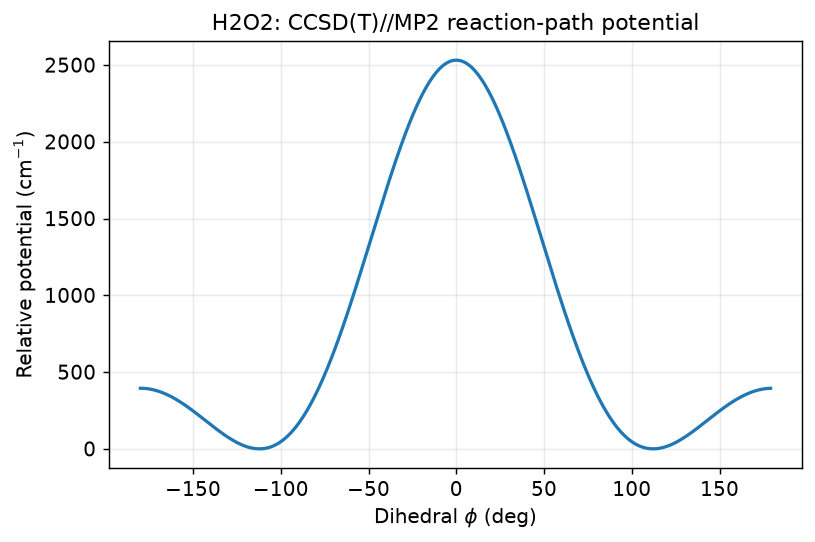

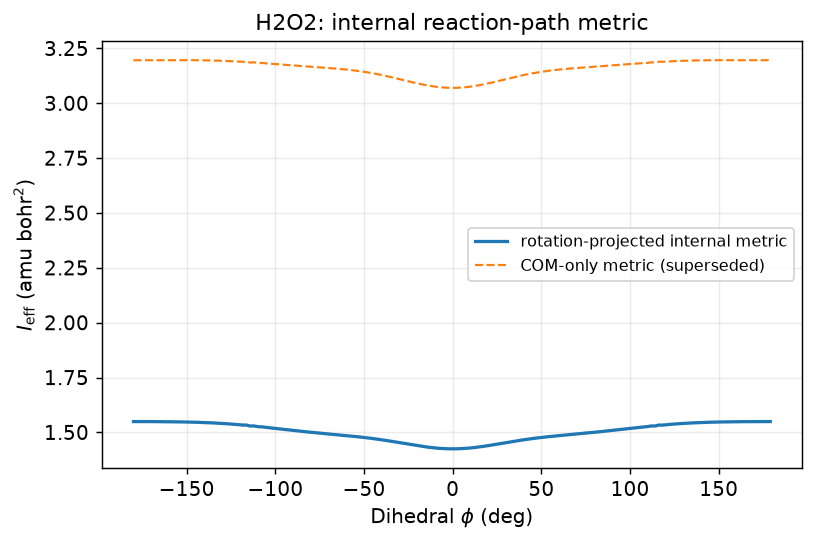

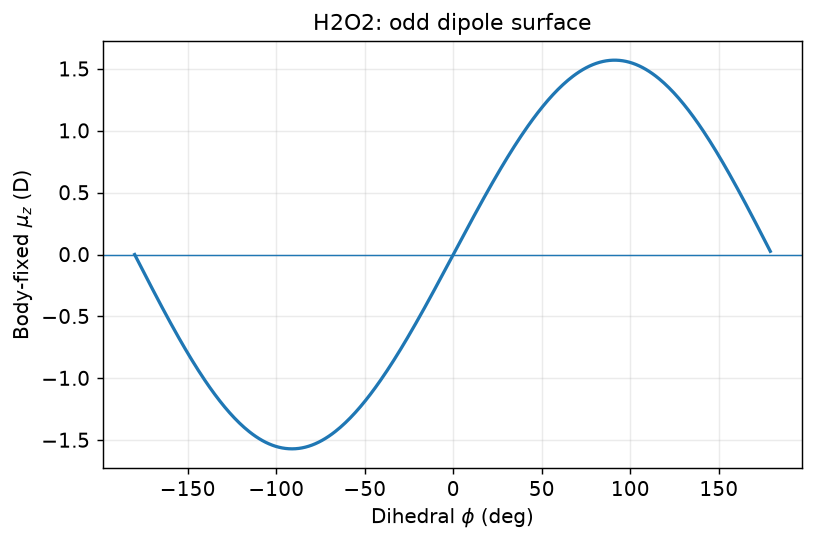

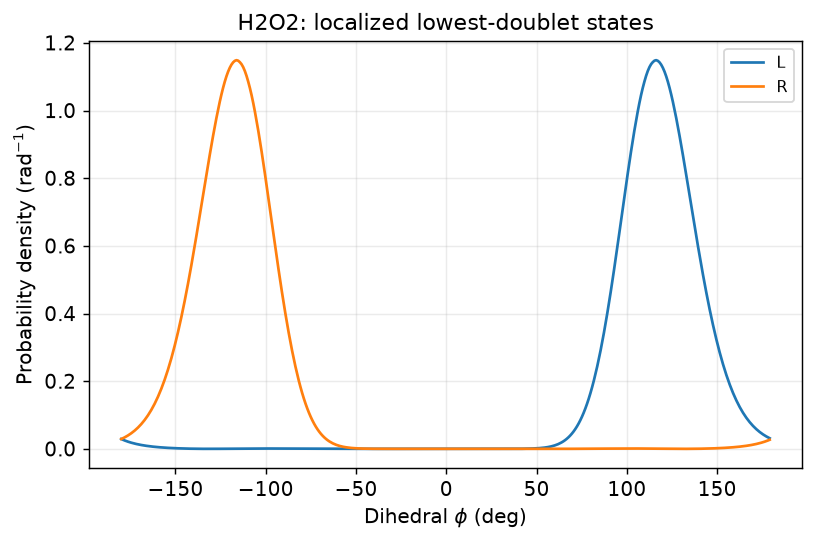

In [16]:
plt.rcParams.update({"font.size":11,"axes.labelsize":11,"axes.titlesize":12,
                     "legend.fontsize":9,"figure.dpi":130})

def save_fig(fig,name):
    fig.savefig(FIG_DIR/f"{name}.pdf",bbox_inches="tight")
    fig.savefig(FIG_DIR/f"{name}.png",dpi=600,bbox_inches="tight")

order=np.argsort(DVR["phi"])
phdeg=np.rad2deg(DVR["phi"])[order]

fig,ax=plt.subplots(figsize=(6.4,4.3))
ax.plot(phdeg,(DVR["Vha"]*HARTREE_TO_CM)[order],lw=1.8)
ax.set_xlabel(r"Dihedral $\phi$ (deg)")
ax.set_ylabel(r"Relative potential (cm$^{-1}$)")
ax.set_title(f"{MOLECULE}: CCSD(T)//MP2 reaction-path potential")
ax.grid(alpha=.25)
fig.tight_layout(); save_fig(fig,"potential"); plt.show()

fig,ax=plt.subplots(figsize=(6.4,4.3))
ax.plot(phdeg,DVR["Ieff"][order],lw=1.8,label="rotation-projected internal metric")
ax.plot(phdeg,np.asarray(ARC_RAW["I_of_phi"](DVR["phi"]))[order],lw=1.2,ls="--",label="COM-only metric (superseded)")
ax.set_xlabel(r"Dihedral $\phi$ (deg)")
ax.set_ylabel(r"$I_{\rm eff}$ (amu bohr$^2$)")
ax.set_title(f"{MOLECULE}: internal reaction-path metric")
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout(); save_fig(fig,"effective_inertia"); plt.show()

fig,ax=plt.subplots(figsize=(6.4,4.3))
ax.plot(phdeg,DVR["mu_z_D"][order],lw=1.8)
ax.axhline(0,lw=.8)
ax.set_xlabel(r"Dihedral $\phi$ (deg)")
ax.set_ylabel(r"Body-fixed $\mu_z$ (D)")
ax.set_title(f"{MOLECULE}: odd dipole surface")
ax.grid(alpha=.25)
fig.tight_layout(); save_fig(fig,"dipole_surface"); plt.show()

fig,ax=plt.subplots(figsize=(6.4,4.3))
probL=phi_probability_density(DVR["L"],DVR)[order]
probR=phi_probability_density(DVR["R"],DVR)[order]
ax.plot(phdeg,probL,label="L")
ax.plot(phdeg,probR,label="R")
ax.set_xlabel(r"Dihedral $\phi$ (deg)")
ax.set_ylabel(r"Probability density (rad$^{-1}$)")
ax.set_title(f"{MOLECULE}: localized lowest-doublet states")
ax.legend(); ax.grid(alpha=.25)
fig.tight_layout(); save_fig(fig,"localized_states"); plt.show()


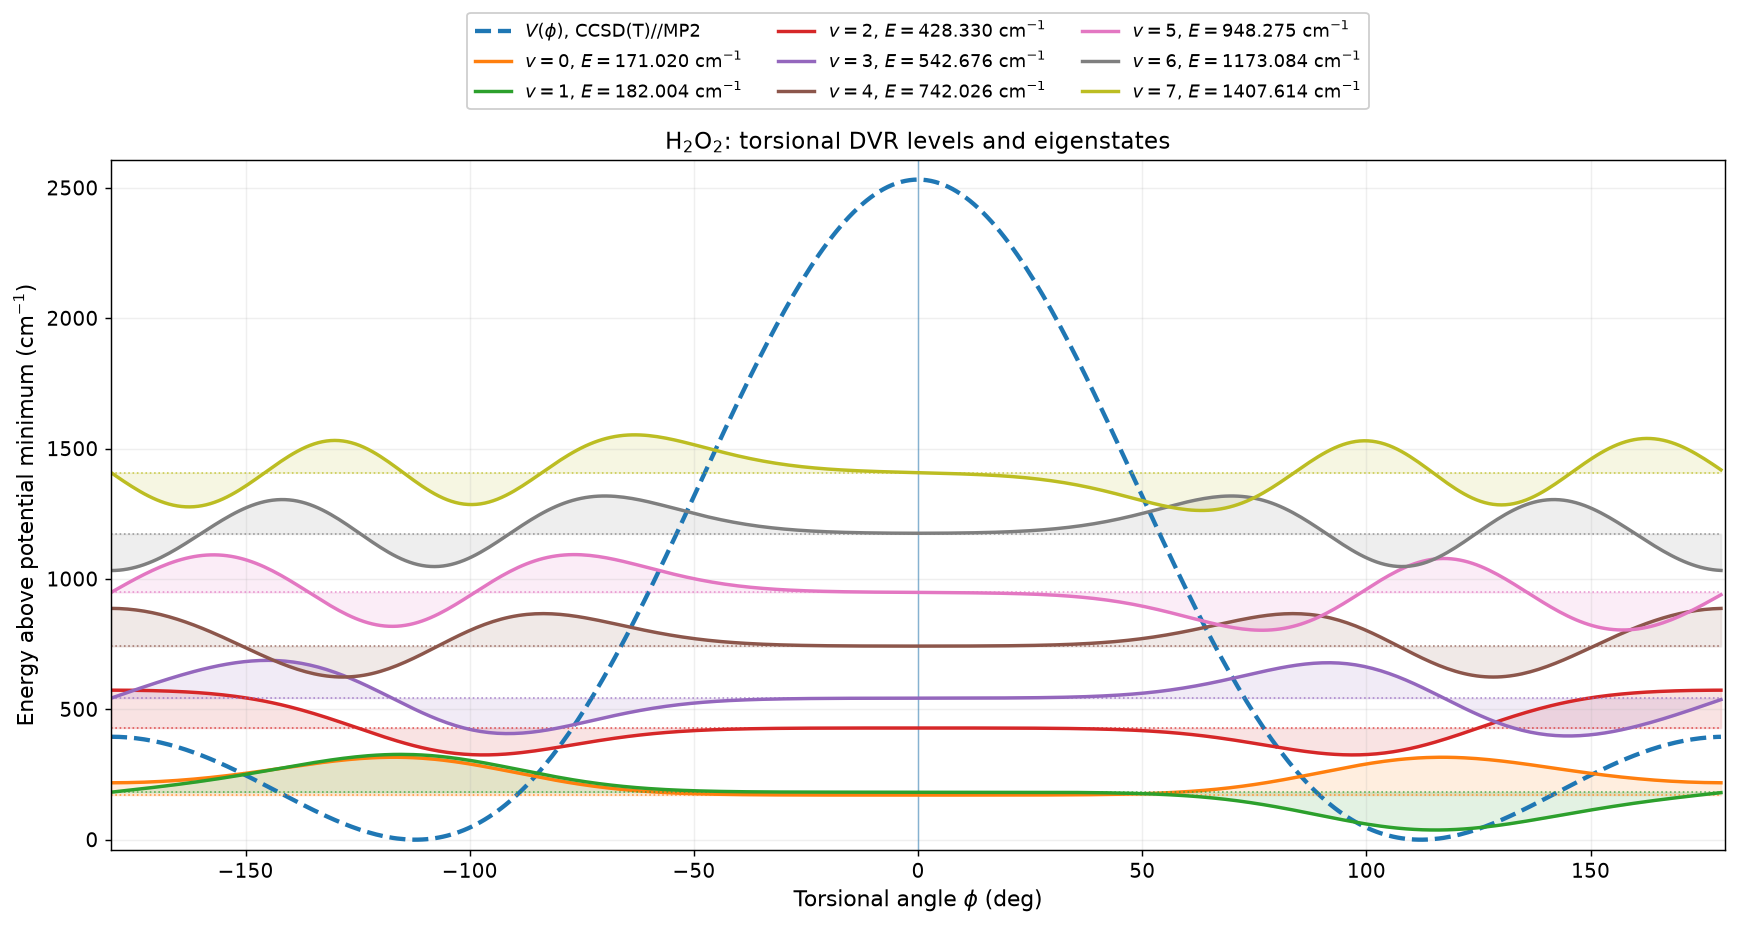

Saved figure:
  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/figures/torsional_DVR_levels_eigenstates.pdf
  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/figures/torsional_DVR_levels_eigenstates.png

Saved numerical data:
  /home/smohtash/H2X2_final/H2X2_publication_project/data/H2O2/processed/torsional_DVR_levels_for_plot.csv

Lowest plotted torsional states:
v= 0   even   E=  171.0201 cm^-1
v= 1   odd    E=  182.0042 cm^-1
v= 2   even   E=  428.3305 cm^-1
v= 3   odd    E=  542.6761 cm^-1
v= 4   even   E=  742.0257 cm^-1
v= 5   odd    E=  948.2752 cm^-1
v= 6   even   E= 1173.0841 cm^-1
v= 7   odd    E= 1407.6140 cm^-1


In [27]:
# ============================================================
# H2O2: publication-quality torsional potential +
#       parity-resolved DVR levels + eigenstates
#
# Designed specifically for this corrected notebook:
#   DVR["phi"], DVR["Vha"], DVR["Ee"], DVR["Eo"],
#   DVR["Pe"], DVR["Po"], ARC["dchi_dphi"]
#
# The DVR is uniform in the internal arc coordinate chi.
# For plotting against the physical dihedral phi, the
# wavefunction amplitude is transformed as
#
#       psi_phi(phi) = sqrt(dchi/dphi) * psi_chi(chi(phi))
#
# so that |psi_phi|^2 dphi = |psi_chi|^2 dchi.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import csv

# ------------------------------------------------------------
# USER PLOT SETTINGS
# ------------------------------------------------------------
N_SHOW = 8                 # number of lowest torsional states
WAVE_SCALE_CM = 145.0      # vertical wavefunction amplitude in cm^-1
FIGSIZE = (13.5, 7.2)

# ------------------------------------------------------------
# 1. Physical dihedral grid and potential
# ------------------------------------------------------------
phi_rad = np.asarray(DVR["phi"], dtype=float)
phi_deg = np.rad2deg(phi_rad)

# DVR["Vha"] is already referenced to the minimum of the
# production CCSD(T)//MP2 torsional surface.
V_cm = np.asarray(DVR["Vha"], dtype=float) * HARTREE_TO_CM

# Sort by physical phi because the computational grid is
# uniform in chi rather than phi.
order = np.argsort(phi_deg)

phi_plot = phi_deg[order]
V_plot = V_cm[order]

# ------------------------------------------------------------
# 2. Collect EVEN and ODD parity eigenstates and sort by energy
# ------------------------------------------------------------
states = []

for sector_index, Eha in enumerate(DVR["Ee"]):
    states.append({
        "parity": "even",
        "sector_index": sector_index,
        "Eha": float(Eha),
        "vec_chi": np.asarray(DVR["Pe"][:, sector_index], dtype=complex),
    })

for sector_index, Eha in enumerate(DVR["Eo"]):
    states.append({
        "parity": "odd",
        "sector_index": sector_index,
        "Eha": float(Eha),
        "vec_chi": np.asarray(DVR["Po"][:, sector_index], dtype=complex),
    })

states = sorted(states, key=lambda s: s["Eha"])
states = states[:N_SHOW]

# The potential minimum is zero, so use the actual torsional
# eigenenergy above the potential minimum for the overlay.
for v, state in enumerate(states):
    state["v"] = v
    state["E_cm"] = state["Eha"] * HARTREE_TO_CM

# ------------------------------------------------------------
# 3. Convert chi-grid eigenstates to physical-phi amplitudes
#
# dchi/dphi enters because
#
# |psi_phi(phi)|^2 dphi = |psi_chi(chi)|^2 dchi.
#
# Hence
#
# psi_phi = sqrt(dchi/dphi) psi_chi.
# ------------------------------------------------------------
jac = np.asarray(ARC["dchi_dphi"](phi_rad), dtype=float)

if np.any(jac <= 0.0):
    raise RuntimeError("Non-positive dchi/dphi encountered.")

for state in states:

    psi = state["vec_chi"] * np.sqrt(jac)

    # Remove the arbitrary complex phase of the eigenvector.
    kmax = np.argmax(np.abs(psi))
    phase = np.angle(psi[kmax])

    psi = psi * np.exp(-1j * phase)
    psi = np.real_if_close(psi, tol=1000).real

    # Fix the remaining +/- sign convention for visual
    # reproducibility.
    kmax = np.argmax(np.abs(psi))
    if psi[kmax] < 0:
        psi *= -1.0

    # Normalize only the DISPLAY amplitude.
    # This does not alter any physical DVR quantity.
    amp = np.max(np.abs(psi))

    if amp > 0:
        psi_display = psi / amp
    else:
        psi_display = psi

    state["psi_phi_display"] = psi_display


# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# Production potential
ax.plot(
    phi_plot,
    V_plot,
    linestyle="--",
    linewidth=2.4,
    label=r"$V(\phi)$, CCSD(T)//MP2"
)

# Vertical symmetry line
ax.axvline(
    0.0,
    linewidth=0.8,
    alpha=0.50
)

# ------------------------------------------------------------
# Plot each state around its physical torsional energy
# ------------------------------------------------------------
for state in states:

    v = state["v"]
    Ecm = state["E_cm"]

    psi_display = state["psi_phi_display"][order]

    y = Ecm + WAVE_SCALE_CM * psi_display

    # Draw wavefunction first so Matplotlib chooses a color.
    line, = ax.plot(
        phi_plot,
        y,
        linewidth=1.9,
        label=fr"$v={v}$, $E={Ecm:.3f}$ cm$^{{-1}}$"
    )

    # Energy reference line
    ax.hlines(
        Ecm,
        phi_plot.min(),
        phi_plot.max(),
        linestyles=":",
        linewidth=0.9,
        alpha=0.75,
        color=line.get_color()
    )

    # Shade wavefunction relative to its energy level.
    ax.fill_between(
        phi_plot,
        Ecm,
        y,
        alpha=0.13,
        color=line.get_color()
    )


# ------------------------------------------------------------
# 5. Labels and publication formatting
# ------------------------------------------------------------
ax.set_xlabel(
    r"Torsional angle $\phi$ (deg)",
    fontsize=12
)

ax.set_ylabel(
    r"Energy above potential minimum (cm$^{-1}$)",
    fontsize=12
)

ax.set_title(
    r"H$_2$O$_2$: torsional DVR levels and eigenstates",
    fontsize=13
)

ax.set_xlim(-180, 180)

# Give the highest plotted state and potential enough room.
highest_state = max(s["E_cm"] for s in states)

ymax = max(
    np.max(V_plot),
    highest_state + 1.25 * WAVE_SCALE_CM
)

ax.set_ylim(
    min(-40.0, np.min(V_plot) - 20.0),
    1.03 * ymax
)

ax.grid(alpha=0.20)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=3,
    framealpha=0.95,
    fontsize=10
)

fig.tight_layout(rect=[0, 0, 1, 0.90])

fig.tight_layout()


# ------------------------------------------------------------
# 6. Save with the notebook's existing figure system
# ------------------------------------------------------------
save_fig(
    fig,
    "torsional_DVR_levels_eigenstates"
)

plt.show()


# ------------------------------------------------------------
# 7. Save the exact level data used in the figure
# ------------------------------------------------------------
level_plot_csv = PROC_DIR / "torsional_DVR_levels_for_plot.csv"

with level_plot_csv.open("w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([
        "v",
        "parity",
        "sector_index",
        "energy_above_potential_minimum_cm-1",
        "energy_ha"
    ])

    for state in states:

        writer.writerow([
            state["v"],
            state["parity"],
            state["sector_index"],
            state["E_cm"],
            state["Eha"]
        ])

print("Saved figure:")
print(" ", FIG_DIR / "torsional_DVR_levels_eigenstates.pdf")
print(" ", FIG_DIR / "torsional_DVR_levels_eigenstates.png")

print("\nSaved numerical data:")
print(" ", level_plot_csv)

print("\nLowest plotted torsional states:")
for state in states:
    print(
        f"v={state['v']:2d}   "
        f"{state['parity']:4s}   "
        f"E={state['E_cm']:10.4f} cm^-1"
    )

In [17]:
# Barriers from production surface.
idx_cis=int(np.argmin(np.abs(A["phi"]-0.0)))
idx_trans=int(np.argmin(np.abs(A["phi"]-180.0)))
imin=int(np.argmin(A["Euse"]))
cis_cm=float((A["Euse"][idx_cis]-A["Euse"][imin])*HARTREE_TO_CM)
trans_cm=float((A["Euse"][idx_trans]-A["Euse"][imin])*HARTREE_TO_CM)
cis_kcal=cis_cm/HARTREE_TO_CM*HARTREE_TO_KCAL
trans_kcal=trans_cm/HARTREE_TO_CM*HARTREE_TO_KCAL

split_factor=factor_error(DVR["Delta_cm"],CFG["benchmark_primary_cm"])
if split_factor<=QUANTITATIVE_SPLIT_FACTOR:
    split_status="PASS_quantitative"
elif split_factor<=ORDER_ONLY_SPLIT_FACTOR:
    split_status="CAUTION_order_only"
else:
    split_status="FAIL_1D_not_quantitative"

t1max=float(np.nanmax(A["t1"]))
t1_status="PASS" if t1max<T1_CAUTION else ("CAUTION" if t1max<T1_FAIL else "FAIL")

dvr_status="PASS" if last3_factor<=DVR_LAST3_FACTOR_TOL else "FAIL"
dipole_status="PASS" if abs(DVR["mu01_D"])>=DIRECT_DIPOLE_DARK_D else "DARK_direct_drive"

freq_status="NOT_RUN"
if freq_records:
    counts={}
    for rec in freq_records:
        counts.setdefault(rec[0],rec[4])
    freq_status="PASS" if counts.get("gauche")==0 and counts.get("cis")==1 and counts.get("trans")==1 else "CAUTION"

basis_status="NOT_RUN"
if np.isfinite(basis_barrier_shift_max):
    basis_status="PASS" if basis_barrier_shift_max<=BASIS_BARRIER_SHIFT_CAUTION_KCAL else "CAUTION"

Iprod=np.asarray(ARC["I_pos"],float)
Iraw=np.asarray(ARC_RAW["I_pos"],float)
kinetic_status="PASS" if MAX_INERTIA_CROSSCHECK<=5e-6 else "FAIL"

summary={
    "molecule":MOLECULE,
    "surface_source":A["source"],
    "scan_step_deg":SCAN_STEP_DEG,
    "n_scan_points":len(SCAN),
    "phi_min_deg":float(A["phi"][imin]),
    "barriers":{
        "cis_cm-1":cis_cm,"trans_cm-1":trans_cm,
        "cis_kcal_mol":cis_kcal,"trans_kcal_mol":trans_kcal,
        "Sahu_MP2_reference_cm-1":CFG["sahu_barrier_cm"],
    },
    "reaction_path_kinetics":{
        "production_model":"COM + rigid-rotation projected tangent; one-dimensional internal arc-length Fourier DVR at J=0",
        "Ieff_projected_min_amu_bohr2":float(np.min(Iprod)),
        "Ieff_projected_max_amu_bohr2":float(np.max(Iprod)),
        "Ichi_projected_amu_bohr2":float(ARC["I_chi_amu_bohr2"]),
        "Ichi_COM_only_superseded_amu_bohr2":float(ARC_RAW["I_chi_amu_bohr2"]),
        "max_Kabsch_projector_relative_difference":float(MAX_INERTIA_CROSSCHECK),
        "status":kinetic_status,
        "quantization":"metric flattened to chi(phi)=pi*s(phi)/s(pi), then constant-metric periodic Fourier DVR",
    },
    "tunneling":{
        "DVR_predicted_cm-1":float(DVR["Delta_cm"]),
        "DVR_signed_cm-1":float(DVR["Delta_cm_signed"]),
        "benchmark_primary_cm-1":float(CFG["benchmark_primary_cm"]),
        "benchmark_label":CFG["benchmark_label"],
        "benchmark_alternatives":CFG["benchmark_alternatives"],
        "factor_error":float(split_factor),
        "status":split_status,
        "last3_DVR_grid_factor":float(last3_factor),
        "DVR_grid_status":dvr_status,
        "experimental_multilevel_RMS_cm-1":None if not np.isfinite(spectroscopy_rms_cm) else float(spectroscopy_rms_cm),
    },
    "control_matrix_element":{
        "mu01_D":float(DVR["mu01_D"]),
        "status":dipole_status,
        "property_level":"PBE0 body-fixed odd dipole surface projected on the rotation-corrected internal-path DVR wavefunctions",
        "CCSD_sparse_diagnostic":"unrelaxed CCSD 1-RDM only; see validation CSV",
    },
    "electronic_structure":{
        "max_T1_diagnostic":t1max,
        "T1_status":t1_status,
        "basis_barrier_shift_max_kcal_mol":None if not np.isfinite(basis_barrier_shift_max) else float(basis_barrier_shift_max),
        "basis_status":basis_status,
        "stationary_point_status":freq_status,
    },
    "claim_guardrails":{
        "one_dimensional_reaction_path":"This is a relaxed 1D J=0 internal path with rigid translation/rotation projected out, not a multidimensional instanton or full torsion-rotation Hamiltonian.",
        "no_empirical_tuning":"The ab initio potential and projected metric are not fitted or rescaled to reproduce the 11.44 cm^-1 benchmark.",
        "racemate":"A closed two-level unitary cannot generate ee from rho=I/2; control results later are stereomutation of a prepared handed state unless an auxiliary/dissipative resource is added.",
        "lab_frame":"mu01 is a body-fixed internal transition moment. Laboratory Rabi rates require rotational-state/orientation factors.",
    }
}

summary_path=PROC_DIR/"summary.json"
summary_path.write_text(json.dumps(summary,indent=2))
(META_DIR/"run_metadata_final.json").write_text(json.dumps(base_metadata(),indent=2))

print(json.dumps(summary,indent=2))


{
  "molecule": "H2O2",
  "surface_source": "CCSD(T)//MP2",
  "scan_step_deg": 5.0,
  "n_scan_points": 44,
  "phi_min_deg": 111.5,
  "barriers": {
    "cis_cm-1": 2531.807056236213,
    "trans_cm-1": 394.6620474282865,
    "cis_kcal_mol": 7.238799784591306,
    "trans_kcal_mol": 1.128395442643755,
    "Sahu_MP2_reference_cm-1": {
      "cis": 2924.3,
      "trans": 368.4
    }
  },
  "reaction_path_kinetics": {
    "production_model": "COM + rigid-rotation projected tangent; one-dimensional internal arc-length Fourier DVR at J=0",
    "Ieff_projected_min_amu_bohr2": 1.4250073250183437,
    "Ieff_projected_max_amu_bohr2": 1.5493396501396424,
    "Ichi_projected_amu_bohr2": 1.5025419850827983,
    "Ichi_COM_only_superseded_amu_bohr2": 3.1592270966535043,
    "max_Kabsch_projector_relative_difference": 1.0551153234319509e-08,
    "status": "PASS",
    "quantization": "metric flattened to chi(phi)=pi*s(phi)/s(pi), then constant-metric periodic Fourier DVR"
  },
  "tunneling": {
    "DVR_pr

In [18]:
def sha256_file(path,chunk=1024*1024):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        while True:
            b=f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

important=[
    RAW_DIR/"torsion_scan.csv",
    RAW_DIR/"optimized_path.xyz",
    PROC_DIR/"dvr_surface.csv",
    PROC_DIR/"dvr_levels.csv",
    PROC_DIR/"dvr_convergence.csv",
    PROC_DIR/"dvr_wavefunctions.npz",
    PROC_DIR/"summary.json",
    VALID_DIR/"electronic_method_sensitivity.csv",
    VALID_DIR/"scan_resolution_sensitivity.csv",
    VALID_DIR/"dipole_method_diagnostic.csv",
    VALID_DIR/"inertia_projection_validation.csv",
    VALID_DIR/"kinetic_model_sensitivity.csv",
]
if (VALID_DIR/"experimental_level_validation.csv").exists():
    important.append(VALID_DIR/"experimental_level_validation.csv")
    
if (VALID_DIR/"stationary_point_frequencies.csv").exists():
    important.append(VALID_DIR/"stationary_point_frequencies.csv")
if (VALID_DIR/"basis_set_sensitivity.csv").exists():
    important.append(VALID_DIR/"basis_set_sensitivity.csv")

hashes={str(p.relative_to(MOL_ROOT)):sha256_file(p) for p in important if p.exists()}
(META_DIR/"file_hashes.json").write_text(json.dumps(hashes,indent=2))
print(json.dumps(hashes,indent=2))
print("\nREADY FOR HANDOFF TO 04 notebook:", PROC_DIR/"summary.json")


{
  "raw/torsion_scan.csv": "1899205b710069cde8fe6b3194dabd81f1c0a24d031ab7c3db934b52c49981bf",
  "raw/optimized_path.xyz": "be3a9b5f3a5ed365490716434bdd054b9302c4141faf6a88fc10631e10cb1a84",
  "processed/dvr_surface.csv": "6d8a072c6982e3af4ed18c3855f4469f0a7745bf373065f1d6ab1d518e17a61b",
  "processed/dvr_levels.csv": "f9b59b71f53f3195982a51532b97033ed6873e3e0b78a0f2fff51027e36a0298",
  "processed/dvr_convergence.csv": "2e6df90fc7266b07420377db4c0066957b697c035cb3464c812dbd413d40195f",
  "processed/dvr_wavefunctions.npz": "57172bba37d308ee4c3ac65848b88d9e1bb574441c21dc44457bde4547223552",
  "processed/summary.json": "2d80c0230a904e03d2913dc85459ad7dce17d8c9b36990bb41966c6e1ca57c63",
  "validation/electronic_method_sensitivity.csv": "d1116885aed25f62396bceadaf0eba863cda63f24f3a3b139c02fd7b6084ee80",
  "validation/scan_resolution_sensitivity.csv": "a17f94d0c29d70ffaff6a9f7d8edf51a6f329cd311d43021c4a9f070c3dbff4f",
  "validation/dipole_method_diagnostic.csv": "e3b1027b2651d48fb6a07618639